# MAUVE Setonix proposal: one 8900-Angstrom reference pass

**Dated 2026-09-29.** This notebook uses local Setonix nGIST v7.6.8 logs to estimate **one complete 4800-8900 Angstrom pass over 40 galaxies represented by 39 datacubes**. It then adds **one 20% SU allowance** for tests, retries, and related science. The number of future configurations is deliberately left open: multiply the buffered single-pass cost by the number of comparable passes selected later.

On Setonix CPU, one requested physical core for one wall-clock hour is one Pawsey service unit (SU); a 128-core node-hour is 128 SU. Source: [2027 Pawsey Partner Scheme, accounting model](https://pawsey.atlassian.net/wiki/spaces/US/pages/51931328/The+Pawsey+Partner+Merit+Allocation+Scheme). The [2027 call](https://pawsey.atlassian.net/wiki/spaces/US/pages/51931328/The+Pawsey+Partner+Merit+Allocation+Scheme) closes **Friday 2 October 2026, 5 pm AWST**.

Direct evidence is the 8900-Angstrom full-run LOGFILE timing. The available efficiency reports supply regular-job memory for some cubes but no scheduler elapsed time or charged SU. Seven cube runtimes require explicitly labelled size-band proxies.

## Inputs and editable planning parameters

The 2025 justification is [`Computational-Methodology.pdf`](/Users/Igniz/Desktop/ICRAR/MAUVE/Computational-Methodology.pdf). Its 40-galaxy by 120-realisation calculation used CANFAR-era assumptions. The current reference uses measured Setonix nGIST full runs with `READ_DATA` 4800-8900 Angstrom, `GAS.LEVEL=BOTH`, SFH enabled, and `GENERAL.NCPU=128` in the product `CONFIG` files. The setup requests one 128-physical-core node and either 230 GiB (`work`/`long`) or 980 GiB (`highmem`). [Pawsey partition limits](https://pawsey.atlassian.net/wiki/spaces/US/pages/51925964/Job+Scheduling) are 24 hours for `work` and 96 hours for `long`/`highmem`.

The default 39 cube IDs come from the setup repository's `27_galaxies.sh` allowlist. The size CSV has 37 of these IDs. For **NGC4548 and NGC4579**, use the user's revised **50 GiB input size each** in the uncompressed FITS-size column. A **22 GiB plot-based boundary** separates small and large runtime-proxy groups; this is a heuristic grouping, not the rule by which Slurm selects the `highmem` queue. `SELECTED_CUBE_IDS`, `ASSUMED_UNSIZED_INPUT_GIB`, `SIZE_CUT_GIB`, and `CONTINGENCY_FRACTION` are editable below.

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import csv, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ICRAR = Path('/Users/Igniz/Desktop/ICRAR')
LOG_ROOT = ICRAR / 'further/v3tk_v7.6.8'
SIZE_CSV = ICRAR / 'nGIST_v7.6.8_setup/config_setup/cube_sizes_v3tk.csv'
RUN_ID_FILE = ICRAR / 'nGIST_v7.6.8_setup/config_setup/27_galaxies.sh'
STATUS_REPORT = ICRAR / 'nGIST_v7.6.8_setup/config_setup/27_status_log_20260929_105522.txt'
REGULAR_EFFICIENCY_FILES = [
    ICRAR / 'further/finished_efficiency_20260528_111829.txt',
    ICRAR / 'nGIST_v7.6.8_setup/config_setup/finished_efficiency_20260728_110558.txt',
]
CORES_PER_JOB = 128
ALLOCATION_PER_QUARTER_SU = 300_000
ALLOCATION_PER_YEAR_SU = 1_200_000
REPORTED_QUARTER_USED_SU = 291_884

SELECTED_CUBE_IDS = None  # None = all 39 IDs in RUN_ID_FILE
SIZE_CUT_GIB = 22.0  # small <22 GiB; large >=22 GiB, a runtime-proxy heuristic
ASSUMED_UNSIZED_INPUT_GIB = 50.0  # GiB for NGC4548 and NGC4579
CONTINGENCY_FRACTION = 0.20  # one allowance per reference pass
PARTNER_MINIMUM_REQUEST_SU = 1_000_000  # scheme floor, separate from measured work

# User-supplied storage figures in decimal TB, not derived from FITS input GiB.
CURRENT_COMPLETED_GALAXIES = 36  # 35 completed cube IDs include NGC4567_8
CURRENT_SCRATCH_TB = 14.0
ALL_INPUT_CUBES_TB = 1.5
OUTPUT_TB_PER_PASS_CURRENT = 8.0  # one output family for 35 finished cubes
STORAGE_HEADROOM_FRACTION = 0.15  # planning choice
SCRATCH_HEADROOM_FRACTION = 0.25  # planning choice

assert SIZE_CUT_GIB > 0 and ASSUMED_UNSIZED_INPUT_GIB > 0
assert 0 <= CONTINGENCY_FRACTION < 1
assert all(x > 0 for x in (CURRENT_COMPLETED_GALAXIES, CURRENT_SCRATCH_TB,
                          ALL_INPUT_CUBES_TB, OUTPUT_TB_PER_PASS_CURRENT))
assert STORAGE_HEADROOM_FRACTION >= 0 and SCRATCH_HEADROOM_FRACTION >= 0

## Cube inventory and completed attempts

`cube_sizes_v3tk.csv` records uncompressed FITS byte counts, cube footprints, and available spaxels. Although its column is called `size_GB`, it is bytes / 2^30 and therefore **GiB**. The spatial footprint is a useful descriptor; runtime also depends on unmasked spectra, Voronoi bins, fitting choices, and I/O. This code chooses `.fits` rows and checks duplicate size records rather than counting `.fits.gz` copies as new cubes.

nGIST appends attempts to a product `LOGFILE`. Segmenting at `_initialise` and ending a successful attempt at its own `MainPipeline: nGIST completed successfully` line avoids a bug in the older May 2026 analysis helper, which can include a later attempt's initialization in an earlier wall time. Only successful attempts that actually performed BIN and SPAXEL gas fitting and SFH, with no skipped modules, enter the full-run baseline. Failed, timed-out, and resumed attempts remain visible for audit but are **not** mistaken for cheap full runs.

In [2]:
raw_sizes = [r for r in csv.DictReader(SIZE_CSV.open(newline=''))
             if r['status'] == 'ok' and r['file'].endswith('.fits')]
sizes = pd.DataFrame({
    'cube_id': r['ID'], 'input_fits': r['file'],
    'input_bytes': int(r['size_B']), 'input_gib': int(r['size_B']) / 2**30,
    'footprint_spaxels': int(r['total_spaxels']),
    'available_spaxels': int(r['available_spaxels'])
} for r in raw_sizes)
assert len(sizes) > 0
for cube_id, group in sizes.groupby('cube_id'):
    assert group['input_bytes'].nunique() == 1, f'Conflicting input sizes: {cube_id}'
    assert group['footprint_spaxels'].nunique() == 1, f'Conflicting footprint: {cube_id}'
sizes = sizes.drop_duplicates('cube_id').sort_values('input_gib').reset_index(drop=True)

TIMESTAMP_RE = re.compile(r'^(\d{2}/\d{2}/\d{2} \d{2}:\d{2}:\d{2})')
def log_time(line):
    m = TIMESTAMP_RE.match(line)
    return datetime.strptime(m.group(1), '%m/%d/%y %H:%M:%S') if m else None

def elapsed_hours(start, end):
    return (end - start).total_seconds() / 3600 if start and end else np.nan

attempts = []
for path in sorted(LOG_ROOT.glob('*/LOGFILE')):
    lines = path.read_text(errors='replace').splitlines()
    boundaries = [i for i, line in enumerate(lines) if '_initialise:' in line] + [len(lines)]
    for attempt_no, (first, stop) in enumerate(zip(boundaries, boundaries[1:]), 1):
        segment = lines[first:stop]
        times = [t for line in segment if (t := log_time(line)) is not None]
        if not times:
            continue
        completion_lines = [line for line in segment if 'MainPipeline: nGIST completed successfully.' in line]
        successful = bool(completion_lines)
        end = log_time(completion_lines[0]) if successful else times[-1]
        mode = None
        bin_fit_seconds = spaxel_fit_seconds = np.nan
        spaxel_result = spaxel_bestfit = None
        for line in segment:
            if 'full spectral library for ppxf on BIN level' in line:
                mode = 'BIN'
            elif 'full spectral library for ppxf on SPAXEL level' in line:
                mode = 'SPAXEL'
            elif 'ppxf_gas_wrapper: Running PPXF on' in line:
                m = re.search(r'took ([0-9.]+)s', line)
                if m and mode == 'BIN':
                    bin_fit_seconds = float(m.group(1))
                elif m and mode == 'SPAXEL':
                    spaxel_fit_seconds = float(m.group(1))
            elif f'{path.parent.name}_gas_spaxel.fits' in line and 'Wrote:' in line:
                spaxel_result = log_time(line)
            elif f'{path.parent.name}_gas_bestfit_spaxel.fits' in line and 'Wrote:' in line:
                spaxel_bestfit = log_time(line)
        sfh_done = any('_writeFITS: Produced SFH maps in FITS format' in line for line in segment)
        skipped = sum('Module is skipped.' in line for line in segment)
        full_run = (successful and skipped == 0 and np.isfinite(bin_fit_seconds)
                    and np.isfinite(spaxel_fit_seconds) and sfh_done)
        attempts.append({
            'cube_id': path.parent.name, 'attempt': attempt_no,
            'log_path': str(path), 'start': times[0], 'end': end,
            'wall_hours': elapsed_hours(times[0], end),
            'successful': successful, 'skipped_modules': skipped,
            'full_run': full_run, 'gas_bin_fit_hours': bin_fit_seconds / 3600,
            'gas_spaxel_fit_hours': spaxel_fit_seconds / 3600,
            'spaxel_bestfit_write_hours': elapsed_hours(spaxel_result, spaxel_bestfit),
        })
attempts = pd.DataFrame(attempts)
observed = (attempts[attempts['full_run']].sort_values(['cube_id', 'end'])
            .drop_duplicates('cube_id', keep='last')
            .merge(sizes, on='cube_id', how='inner', validate='one_to_one'))
observed['measured_su'] = CORES_PER_JOB * observed['wall_hours']
observed['size_band'] = pd.cut(
    observed['input_gib'], [0, SIZE_CUT_GIB, np.inf],
    labels=[f'small (<{SIZE_CUT_GIB:g} GiB)', f'large (>={SIZE_CUT_GIB:g} GiB)'],
    right=False)
print(f'{len(attempts)} logged attempts; {int(attempts.successful.sum())} successful; '
      f'{len(observed)} distinct successful full runs with cube-size rows.')
print('Excluded from full-run baseline:')
display(attempts.loc[~attempts.full_run,
                     ['cube_id','attempt','wall_hours','successful','skipped_modules']]
        .round(2).reset_index(drop=True))

41 logged attempts; 37 successful; 32 distinct successful full runs with cube-size rows.
Excluded from full-run baseline:


,cube_id,attempt,wall_hours,successful,skipped_modules
0,IC3392,2,0.01,True,7
1,NGC4064,2,0.02,True,7
2,NGC4222,1,0.56,False,0
3,NGC4222,2,12.59,True,5
4,NGC4298,1,1.81,False,0
5,NGC4298,2,0.24,False,5
6,NGC4298,3,34.65,True,5
7,NGC4450,1,2.76,False,0
8,NGC4450,2,15.22,True,5


In [3]:
band_stats = (observed.groupby('size_band', observed=True)['wall_hours']
              .agg(n='size', min_h='min', max_h='max'))
band_stats['max_su'] = CORES_PER_JOB * band_stats['max_h']
print(f'Two runtime-proxy groups at {SIZE_CUT_GIB:g} GiB; '
      'actual Slurm partitions are assigned by job scripts.')
display(band_stats.round(2))
display(observed[['cube_id','input_gib','footprint_spaxels','available_spaxels',
                  'wall_hours','measured_su','gas_spaxel_fit_hours',
                  'spaxel_bestfit_write_hours','log_path']]
        .sort_values('input_gib').round(2).reset_index(drop=True))
print(f'Observed full-run range: {observed.wall_hours.min():.2f}-{observed.wall_hours.max():.2f} h; '
      f'{observed.measured_su.min():,.0f}-{observed.measured_su.max():,.0f} SU/job.')
print(f'Total for these {len(observed)} distinct '
      f'cube IDs ({len(observed) + int("NGC4567_8" in set(observed.cube_id))} galaxies): {observed.measured_su.sum():,.0f} SU for one pass.')

Two runtime-proxy groups at 22 GiB; actual Slurm partitions are assigned by job scripts.
Observed full-run range: 3.22-90.25 h; 413-11,552 SU/job.
Total for these 32 distinct cube IDs (33 galaxies): 81,077 SU for one pass.


,n,min_h,max_h,max_su
size_band,,,,
small (<22 GiB),23,3.22,29.17,3733.80
large (>=22 GiB),9,10.90,90.25,11552.43


,cube_id,input_gib,footprint_spaxels,available_spaxels,wall_hours,measured_su,gas_spaxel_fit_hours,spaxel_bestfit_write_hours,log_path
0,NGC4607,5.94,188370,181002,3.54,452.94,2.60,0.38,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
1,NGC4606,5.95,188790,96725,3.22,412.55,1.66,0.73,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
2,NGC4189,6.01,190762,180181,3.46,442.52,2.12,0.41,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
3,NGC4351,6.02,190893,182908,5.03,643.56,2.46,2.06,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
4,IC3392,6.03,191406,96287,5.11,653.94,1.63,2.72,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
5,NGC4424,6.04,191620,176952,5.40,691.16,2.42,1.84,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
6,NGC4694,6.10,193599,96349,5.75,736.50,1.64,2.79,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
7,NGC4388,8.86,281010,269889,8.51,1089.10,4.23,1.21,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
8,NGC4405,10.91,346086,181175,6.56,840.28,3.01,2.31,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...
9,NGC4402,11.55,366336,350462,7.98,1022.08,5.88,0.26,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...


## Latest regular-product status (29 September 2026)

The [`27_status_log_20260929_105522.txt`](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/27_status_log_20260929_105522.txt) report marks 35 of 39 regular 8900-Angstrom cube products as finished. `FINISHED` means a product LOGFILE has the success marker; it does not establish an uninterrupted full-run timing. Its `LAST_TIME` is a final product-log timestamp, not elapsed job time. Three finished cubes needed a skipped-module restart, leaving 32 clean full-run intervals for direct timing.

In [4]:
STATUS_RE = re.compile(r'^(regular|7000)\s+(\S+)\s+(\S+)\s+')
status_rows = [
    {'run': m.group(1), 'cube_id': m.group(2), 'status': m.group(3)}
    for line in STATUS_REPORT.read_text().splitlines()
    if (m := STATUS_RE.match(line))
]
status = pd.DataFrame(status_rows)
assert len(status) == 78 and len(status[['run','cube_id']].drop_duplicates()) == 78
status_inventory_ids = set(
    m.group(1) for line in RUN_ID_FILE.read_text().splitlines()
    if (m := re.match(r'^\s*((?:IC|NGC)\d+(?:_\d+)?)\s*$', line)))
assert set(status.cube_id) == status_inventory_ids
assert status.groupby('run').cube_id.nunique().to_dict() == {'regular': 39, '7000': 39}
display(status.loc[status.run.eq('regular')].groupby('status').size().rename('regular 8900-A cube count'))
missing_by_run = {run: set(group.loc[group.status.eq('MISSING_LOGS'), 'cube_id'])
                  for run, group in status.groupby('run')}
assert missing_by_run['regular'] == missing_by_run['7000']
completed_cube_ids = set(status.loc[(status.run == 'regular') &
                                    status.status.eq('FINISHED'), 'cube_id'])
completed_galaxies = len(completed_cube_ids) + int('NGC4567_8' in completed_cube_ids)
assert completed_galaxies == CURRENT_COMPLETED_GALAXIES
print(f'Latest regular status: {len(completed_cube_ids)} finished cube IDs = '
      f'{completed_galaxies} galaxies; '
      f'{len(missing_by_run["regular"])} missing cubes: '
      f'{", ".join(sorted(missing_by_run["regular"]))}.')

Latest regular status: 35 finished cube IDs = 36 galaxies; 4 missing cubes: NGC4216, NGC4548, NGC4579, NGC4689.


status
FINISHED        35
MISSING_LOGS     4
Name: regular 8900-A cube count, dtype: int64

## Peak memory for the 8900-Angstrom reference

The May/July efficiency reports contain regular 8900-Angstrom jobs. The new [29 September finished-job report](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/finished_efficiency_20260929_130155.txt) contains only 7000-Angstrom jobs and no elapsed-time or charged-SU column, so it does not enter this 8900-Angstrom estimate. The regular reports give `ReqCPU`, `Alloc`, `ReqMem`, and `MaxRSS`; `Alloc=256` counts logical threads on a 128-physical-core node and does not double the SU rate.

Product LOGFILEs have second-resolution timestamps; the efficiency reports round `End` to a minute and appear eight hours ahead of the local log clock. To associate regular-job memory with a full run, require the exact cube/job name and a **unique completion match within 60 seconds** after the inferred eight-hour offset. An earlier exact-minute join lost three valid matches when the scheduler minute rolled forward by 3-6 seconds. This join remains inferred because LOGFILEs do not record Slurm job IDs.

In [5]:
EFF_ROW = re.compile(
    r'^\s*(\d+)\s+(\S+)\s+(\S+)\s+(.+?)\s+'
    r'(\d+)\s+(\d+)\s+([0-9.]+)\s+([0-9.]+%)\s+([0-9.]+%)\s+'
    r'(\S+)\s+(\S+)\s+(\S+)\s+(\S+)'
)
def mem_gib(value):
    m = re.fullmatch(r'([0-9.]+)(GiB|MiB|TiB)', value)
    if not m:
        return np.nan
    return float(m.group(1)) * {'MiB': 1/1024, 'GiB': 1, 'TiB': 1024}[m.group(2)]

efficiency = []
for source_path in REGULAR_EFFICIENCY_FILES:
    for line_no, line in enumerate(source_path.read_text(errors='replace').splitlines(), 1):
        m = EFF_ROW.match(line)
        if not m or m.group(3) != 'COMPLETED':
            continue
        job_name, end_text = m.group(2), m.group(4).strip()
        if not job_name.endswith('_v3tk_v7.6.8'):
            continue
        try:
            scheduler_end = datetime.strptime(end_text + ' 2026', '%d %b %H:%M %Y')
        except ValueError:
            continue
        efficiency.append({
            'job_id': int(m.group(1)),
            'cube_id': job_name[:-len('_v3tk_v7.6.8')],
            'scheduler_end_local_minute': scheduler_end - timedelta(hours=8),
            'req_cpu': int(m.group(5)), 'slurm_alloc': int(m.group(6)),
            'req_mem_gib': mem_gib(m.group(10)),
            'maxrss_gib': mem_gib(m.group(12)),
            'efficiency_source': f'{source_path}:{line_no}',
        })
efficiency = pd.DataFrame(efficiency).drop_duplicates('job_id', keep='last')
candidates = observed[['cube_id','end']].merge(efficiency, on='cube_id', how='left')
candidates['match_offset_s'] = (candidates.end - candidates.scheduler_end_local_minute).abs().dt.total_seconds()
memory_matches = candidates.loc[candidates.match_offset_s.le(60)].copy()
assert not memory_matches.cube_id.duplicated().any(), 'Ambiguous same-cube memory match'
observed = observed.merge(
    memory_matches.drop(columns=['end']), on='cube_id', how='left', validate='one_to_one')
observed['rss_at_limit'] = observed.maxrss_gib >= .98 * observed.req_mem_gib
assert (observed.loc[observed.job_id.notna(), 'req_cpu'] == CORES_PER_JOB).all()
print(f'8900-Angstrom full-run memory matches: '
      f'{observed.maxrss_gib.notna().sum()}/{len(observed)} cube IDs '
      f'(unique same-cube End match within 60 s).')
display(observed.loc[observed.maxrss_gib.notna(),
                     ['cube_id','input_gib','wall_hours','req_mem_gib',
                      'maxrss_gib','job_id','match_offset_s','efficiency_source']]
        .sort_values('input_gib').round(2).reset_index(drop=True))


8900-Angstrom full-run memory matches: 29/32 cube IDs (unique same-cube End match within 60 s).


,cube_id,input_gib,wall_hours,req_mem_gib,maxrss_gib,job_id,match_offset_s,efficiency_source
0,NGC4607,5.94,3.54,230.0,127.0,44853854.0,16.0,/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/...
1,NGC4606,5.95,3.22,230.0,127.0,44853853.0,3.0,/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/...
2,NGC4189,6.01,3.46,230.0,144.0,44853826.0,3.0,/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/...
3,NGC4351,6.02,5.03,230.0,134.0,44853835.0,43.0,/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/...
4,IC3392,6.03,5.11,220.0,113.0,43057897.0,42.0,/Users/Igniz/Desktop/ICRAR/further/finished_ef...
5,NGC4694,6.10,5.75,230.0,125.0,44853855.0,10.0,/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/...
6,NGC4388,8.86,8.51,230.0,162.0,44853838.0,42.0,/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/...
7,NGC4405,10.91,6.56,230.0,167.0,44853841.0,16.0,/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/...
8,NGC4402,11.55,7.98,230.0,209.0,44853842.0,37.0,/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/...
9,NGC4294,11.85,12.97,230.0,186.0,44853830.0,43.0,/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/...


<ipython-input-1-2244964884d3>:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


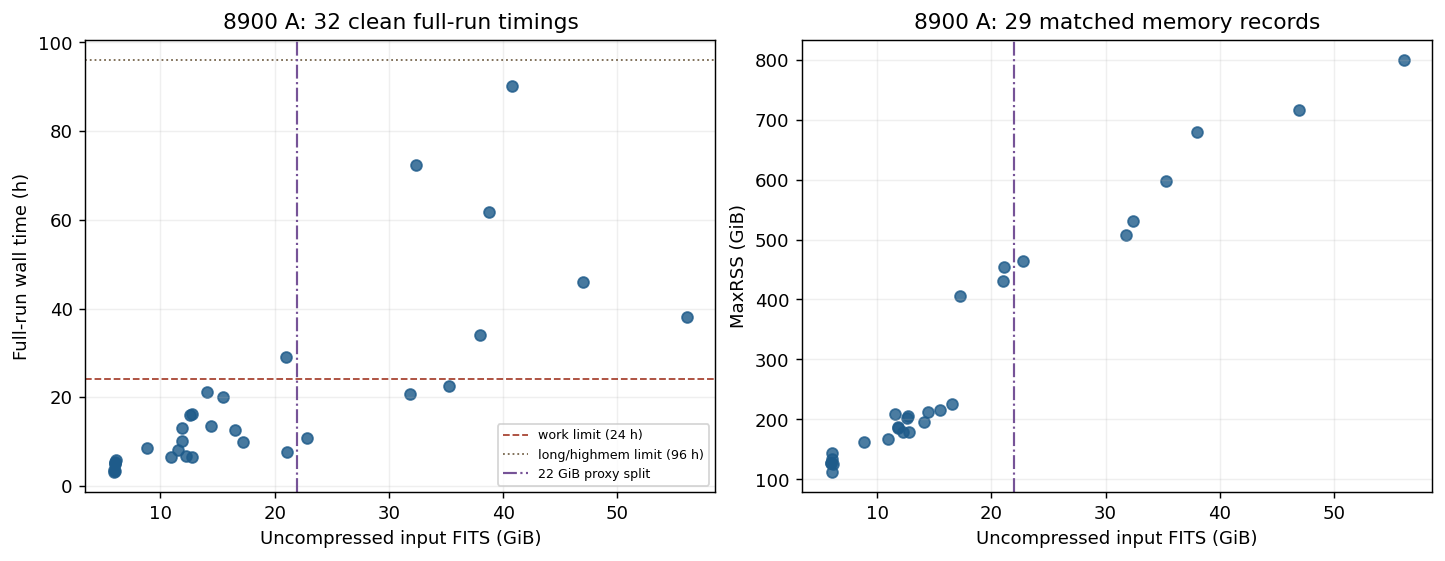

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].scatter(observed.input_gib, observed.wall_hours, c='#1e5b8a', alpha=.82)
axes[0].axhline(24, color='#a84534', linestyle='--', linewidth=1, label='work limit (24 h)')
axes[0].axhline(96, color='#77664d', linestyle=':', linewidth=1, label='long/highmem limit (96 h)')
axes[0].set(xlabel='Uncompressed input FITS (GiB)', ylabel='Full-run wall time (h)',
            title=f'8900 A: {len(observed)} clean full-run timings')
axes[0].axvline(SIZE_CUT_GIB, color='#765397', linestyle='-.', linewidth=1.2,
                label=f'{SIZE_CUT_GIB:g} GiB proxy split')
axes[0].legend(fontsize=7)
regular_peak = observed.dropna(subset=['maxrss_gib'])
axes[1].scatter(regular_peak.input_gib, regular_peak.maxrss_gib, c='#1e5b8a', alpha=.8)
axes[1].axvline(SIZE_CUT_GIB, color='#765397', linestyle='-.', linewidth=1.2)
axes[1].set(xlabel='Uncompressed input FITS (GiB)', ylabel='MaxRSS (GiB)',
            title=f'8900 A: {len(regular_peak)} matched memory records')
for ax in axes: ax.grid(alpha=.2)
plt.show()

## Build one 8900-Angstrom reference pass over all 39 cubes

The diagnostic plots show **32** uninterrupted 8900-Angstrom full-run timings and **29** matched regular-job memory records. Three additional finished products (NGC4222, NGC4298, NGC4450) succeeded after skipped-module restarts, so their final segments are not standalone full-run timings. Four regular products have no finished log. **All 39 cubes** enter the budget below: 32 use direct 8900-Angstrom timings and seven use the maximum measured 8900-Angstrom runtime in their own small or large input-size group.

The plot suggests a rough size separation around **22 GiB**. We use **small <22 GiB** and **large >=22 GiB** for the seven runtime proxies. These are *input FITS-size groups*; actual normal/long/highmem partition assignments are explicit lists in `27_creation.sh` and also depend on memory and time requirements. NGC4548 and NGC4579 are each assumed to be **50 GiB** and therefore use the large-group observed maximum. The five known-size missing timings comprise two small cubes (NGC4222, NGC4450) and three large cubes (NGC4216, NGC4298, NGC4689).

Sum the measured 32 hours and the seven labelled proxies, multiply by **128 physical cores** for one-pass SU, then add **20% once**. For any future number `N` of comparable passes, use `N x buffered_one_pass_su`. The previous `pawsey1308` record of 291,884/300,000 SU used is one quarter; the annual allocation was 1.2 million SU, but annual consumption is not established by that record.

The maximum is a conservative observed proxy, not a guaranteed upper bound for an unmeasured cube. It is separate from the 20% tests/retries allowance.

In [7]:
ID_RE = re.compile(r'^\s*((?:IC|NGC)\d+(?:_\d+)?)\s*$')
run_ids = [m.group(1) for line in RUN_ID_FILE.read_text().splitlines()
           if (m := ID_RE.match(line))]
assert len(run_ids) == 39 and len(run_ids) == len(set(run_ids))
proposal_ids = run_ids if SELECTED_CUBE_IDS is None else list(SELECTED_CUBE_IDS)
assert len(proposal_ids) == len(set(proposal_ids)), 'Duplicate proposal cube IDs'
budget = (pd.DataFrame({'cube_id': proposal_ids})
          .merge(sizes, on='cube_id', how='left', validate='one_to_one')
          .merge(observed[['cube_id','wall_hours','full_run','log_path']],
                 on='cube_id', how='left', validate='one_to_one'))
budget['input_size_source'] = np.where(budget.input_gib.isna(),
                                        'assumed 50 GiB', 'size CSV')
budget['input_gib'] = budget.input_gib.fillna(ASSUMED_UNSIZED_INPUT_GIB)
budget['size_band'] = pd.cut(
    budget.input_gib, [0, SIZE_CUT_GIB, np.inf],
    labels=band_stats.index.categories, right=False).astype(str)
max_by_band = band_stats.max_h.to_dict()
budget['runtime_source'] = np.where(
    budget.wall_hours.notna(), 'measured full run',
    np.where(budget.input_size_source.eq('assumed 50 GiB'),
             'assumed-50-GiB large-group maximum', 'known-size size-group maximum'))
budget['baseline_hours'] = budget.wall_hours.fillna(
    budget.size_band.map(max_by_band).astype(float))
assert budget.baseline_hours.notna().all()
budget['baseline_su'] = CORES_PER_JOB * budget.baseline_hours
measured_hours = budget.loc[budget.runtime_source.eq('measured full run'), 'baseline_hours'].sum()
known_size_proxy_hours = budget.loc[budget.runtime_source.eq('known-size size-group maximum'),
                                    'baseline_hours'].sum()
assumed_size_proxy_hours = budget.loc[budget.runtime_source.eq('assumed-50-GiB large-group maximum'),
                                      'baseline_hours'].sum()
assert budget.runtime_source.value_counts().to_dict() == {
    'measured full run': 32, 'known-size size-group maximum': 5,
    'assumed-50-GiB large-group maximum': 2}
assert budget.loc[budget.input_size_source.eq('assumed 50 GiB'),
                  'size_band'].eq(f'large (>={SIZE_CUT_GIB:g} GiB)').all()
one_pass_hours = budget.baseline_hours.sum()
one_pass_su = CORES_PER_JOB * one_pass_hours
buffer_su = one_pass_su * CONTINGENCY_FRACTION
buffered_one_pass_su = one_pass_su + buffer_su
print(f'All {len(budget)} cubes: 32 measured, five known-size proxies, two assumed-50-GiB proxies.')
print(f'One 8900-Angstrom pass: {measured_hours:.4f} measured h + '
      f'{known_size_proxy_hours:.4f} known-size proxy h + '
      f'{assumed_size_proxy_hours:.4f} assumed-size proxy h = '
      f'{one_pass_hours:.4f} node-hours.')
print(f'{one_pass_hours:.4f} node-hours x {CORES_PER_JOB} cores = '
      f'{one_pass_su:,.2f} SU; plus {CONTINGENCY_FRACTION:.0%} = '
      f'{buffered_one_pass_su:,.2f} SU per buffered pass.')
display(budget[['cube_id','input_gib','input_size_source','size_band','runtime_source',
                'baseline_hours','baseline_su']]
        .sort_values('input_gib').round(2).reset_index(drop=True))

All 39 cubes: 32 measured, five known-size proxies, two assumed-50-GiB proxies.
One 8900-Angstrom pass: 633.4106 measured h + 329.1006 known-size proxy h + 180.5067 assumed-size proxy h = 1143.0178 node-hours.
1143.0178 node-hours x 128 cores = 146,306.28 SU; plus 20% = 175,567.53 SU per buffered pass.


,cube_id,input_gib,input_size_source,size_band,runtime_source,baseline_hours,baseline_su
0,NGC4607,5.94,size CSV,small (<22 GiB),measured full run,3.54,452.94
1,NGC4606,5.95,size CSV,small (<22 GiB),measured full run,3.22,412.55
2,NGC4189,6.01,size CSV,small (<22 GiB),measured full run,3.46,442.52
3,NGC4351,6.02,size CSV,small (<22 GiB),measured full run,5.03,643.56
4,IC3392,6.03,size CSV,small (<22 GiB),measured full run,5.11,653.94
5,NGC4424,6.04,size CSV,small (<22 GiB),measured full run,5.40,691.16
6,NGC4694,6.10,size CSV,small (<22 GiB),measured full run,5.75,736.50
7,NGC4388,8.86,size CSV,small (<22 GiB),measured full run,8.51,1089.10
8,NGC4405,10.91,size CSV,small (<22 GiB),measured full run,6.56,840.28
9,NGC4402,11.55,size CSV,small (<22 GiB),measured full run,7.98,1022.08


<ipython-input-1-8a444fac4468>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


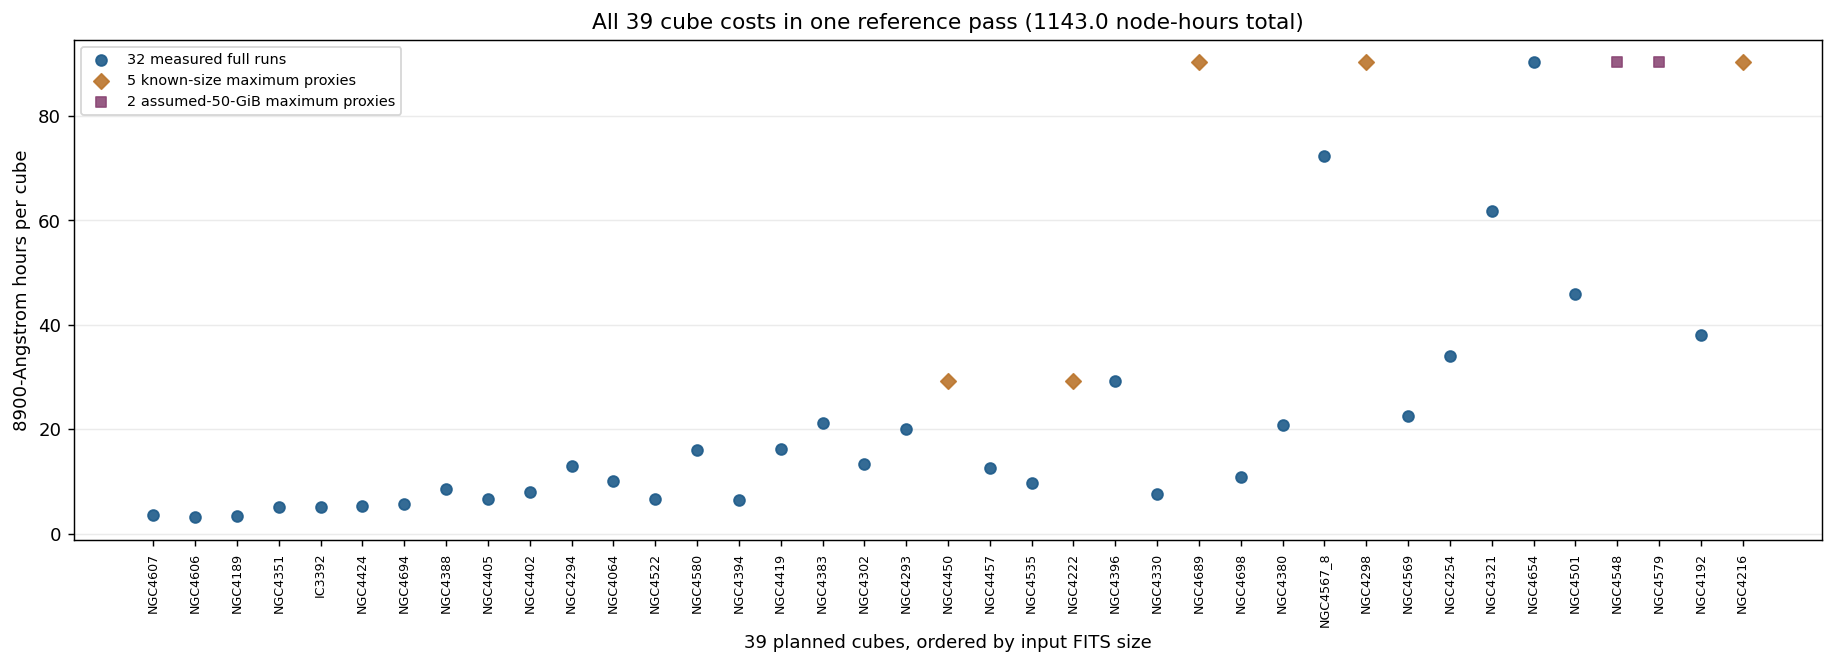

In [8]:
# All 39 budgeted cubes, including explicit proxies.
plot_budget = budget.sort_values(['input_gib','cube_id']).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
style = {
    'measured full run': ('#1e5b8a', 'o', '32 measured full runs'),
    'known-size size-group maximum': ('#bb752c', 'D', '5 known-size maximum proxies'),
    'assumed-50-GiB large-group maximum': ('#8c4a77', 's', '2 assumed-50-GiB maximum proxies'),
}
for source_name, (colour, marker, label) in style.items():
    rows = plot_budget.loc[plot_budget.runtime_source.eq(source_name)]
    ax.scatter(rows.index, rows.baseline_hours, c=colour, marker=marker,
               s=36, alpha=.9, label=label, zorder=3)
ax.set(xticks=plot_budget.index, xticklabels=plot_budget.cube_id,
       xlabel='39 planned cubes, ordered by input FITS size',
       ylabel='8900-Angstrom hours per cube',
       title=f'All {len(plot_budget)} cube costs in one reference pass '
             f'({one_pass_hours:.1f} node-hours total)')
ax.tick_params(axis='x', labelrotation=90, labelsize=7)
ax.grid(axis='y', alpha=.25)
ax.legend(loc='upper left', fontsize=8)
plt.show()

In [9]:
one_pass_ledger = pd.DataFrame([
    ('32 measured full 8900-A runs', measured_hours, measured_hours * CORES_PER_JOB),
    ('5 known-size small/large maximum proxies', known_size_proxy_hours,
     known_size_proxy_hours * CORES_PER_JOB),
    ('2 assumed-50-GiB large-group maximum proxies', assumed_size_proxy_hours,
     assumed_size_proxy_hours * CORES_PER_JOB),
    ('One complete 39-cube reference pass', one_pass_hours, one_pass_su),
    ('20% tests/retries/other-science allowance', np.nan, buffer_su),
    ('One buffered reference pass', np.nan, buffered_one_pass_su),
], columns=['step', 'node_hours', 'su'])
display(one_pass_ledger.round({'node_hours': 2, 'su': 0}))

def scale_reference_passes(n_passes):
    """Return SU for any positive integer of comparable 8900-Angstrom passes."""
    if isinstance(n_passes, bool) or int(n_passes) != n_passes or n_passes < 1:
        raise ValueError('n_passes must be a positive integer')
    return {'passes': int(n_passes), 'jobs': int(n_passes * len(budget)),
            'reference_node_hours': n_passes * one_pass_hours,
            'reference_su': n_passes * one_pass_su,
            'buffer_su': n_passes * buffer_su,
            'total_su': n_passes * buffered_one_pass_su}

print(f'Scale later: SU(N) = N x {buffered_one_pass_su:,.2f} for N comparable passes; '
      f'jobs(N) = N x {len(budget)}.')
print(f'Last-year allocation: {ALLOCATION_PER_QUARTER_SU:,} SU/quarter, '
      f'{ALLOCATION_PER_YEAR_SU:,} SU/year. Reported use '
      f'{REPORTED_QUARTER_USED_SU:,} SU is one quarter only.')
print(f'2027 Partner application floor: {PARTNER_MINIMUM_REQUEST_SU:,} SU/year, '
      'separate from the one-pass accounting.')

Scale later: SU(N) = N x 175,567.53 for N comparable passes; jobs(N) = N x 39.
Last-year allocation: 300,000 SU/quarter, 1,200,000 SU/year. Reported use 291,884 SU is one quarter only.
2027 Partner application floor: 1,000,000 SU/year, separate from the one-pass accounting.


,step,node_hours,su
0,32 measured full 8900-A runs,633.41,81077.0
1,5 known-size small/large maximum proxies,329.10,42125.0
2,2 assumed-50-GiB large-group maximum proxies,180.51,23105.0
3,One complete 39-cube reference pass,1143.02,146306.0
4,20% tests/retries/other-science allowance,NaN,29261.0
5,One buffered reference pass,NaN,175568.0


## Acacia retention and scratch working space

The user's storage inputs are **14 TB currently on `/scratch` for 36 galaxies**, **1.5 TB for all input cubes**, and **8 TB of products for one run type measured for those same 36 galaxies**. The 35 finished cube IDs correspond to 36 galaxies because `NGC4567_8` contains two. These are user-supplied decimal-TB estimates; the local efficiency reports do not measure disk usage.

For 39 cubes, one output family scales to `8 x 39/35 = 8.914 TB`. Retaining the inputs and **one** output family requires `1.5 + 8 x 39/35 = 10.414 TB`. With 15% headroom, this is 11.976 TB, rounded up to a **15 TB one-pass Acacia planning value**. For any future `N` output families retained together, use `Acacia_min(N) = 1.5 + N x (8 x 39/35) TB` and apply headroom and the requested rounding then. This leaves the eventual multi-run request open until retention plans are known.

`/scratch` is active working space, separate from Acacia retention. Scaling the observed 14 TB to 39 cubes gives 15.6 TB, and 25% working headroom gives **19.5 TB**, rounded to a **20 TB conditional target**. That target assumes completed products are moved to Acacia before the next pass; simultaneous retention of multiple output families on scratch requires a larger peak-space estimate. [Pawsey filesystem guidance](https://pawsey.atlassian.net/wiki/spaces/US/pages/51925876/Pawsey+Filesystems+and+their+Use) describes scratch as temporary. The [2027 Partner scheme](https://pawsey.atlassian.net/wiki/spaces/US/pages/51931328/The+Pawsey+Partner+Merit+Allocation+Scheme) has a 0.5 TB default Acacia allocation; [Acacia guidance](https://pawsey.atlassian.net/wiki/spaces/US/pages/51924510/Acacia+-+Troubleshooting) directs requests above 10 TB to a separate managed-storage application.

In [10]:
total_cube_count = len(status_inventory_ids)
completed_cube_count = len(completed_cube_ids)
cube_scale = total_cube_count / completed_cube_count
output_tb_per_pass_full = OUTPUT_TB_PER_PASS_CURRENT * cube_scale
one_pass_acacia_min_tb = ALL_INPUT_CUBES_TB + output_tb_per_pass_full
one_pass_acacia_with_headroom_tb = one_pass_acacia_min_tb * (1 + STORAGE_HEADROOM_FRACTION)
one_pass_acacia_rounded_tb = 5 * math.ceil(one_pass_acacia_with_headroom_tb / 5)
scratch_scaled_tb = CURRENT_SCRATCH_TB * cube_scale
scratch_target_tb = 5 * math.ceil(scratch_scaled_tb
                                  * (1 + SCRATCH_HEADROOM_FRACTION) / 5)

def scale_storage(n_passes):
    """Acacia capacity if the inputs and n output families coexist."""
    if isinstance(n_passes, bool) or int(n_passes) != n_passes or n_passes < 1:
        raise ValueError('n_passes must be a positive integer')
    minimum_tb = ALL_INPUT_CUBES_TB + n_passes * output_tb_per_pass_full
    return {'passes': int(n_passes), 'minimum_acacia_tb': minimum_tb,
            'with_headroom_tb': minimum_tb * (1 + STORAGE_HEADROOM_FRACTION),
            'rounded_request_tb': 5 * math.ceil(
                minimum_tb * (1 + STORAGE_HEADROOM_FRACTION) / 5)}

storage_accounting = pd.DataFrame([
    ('Input cubes, all 39', ALL_INPUT_CUBES_TB),
    ('One output family, projected to 39 cubes', output_tb_per_pass_full),
    ('One-pass Acacia retention minimum', one_pass_acacia_min_tb),
    ('One-pass Acacia with 15% headroom', one_pass_acacia_with_headroom_tb),
    ('Rounded one-pass Acacia planning value', one_pass_acacia_rounded_tb),
    ('Scratch observed for 35 cubes', CURRENT_SCRATCH_TB),
    ('Scratch projected to 39 cubes', scratch_scaled_tb),
    ('Scratch target with 25% headroom', scratch_target_tb),
], columns=['component', 'tb'])
display(storage_accounting.round(2))
print(f'For N retained output families: minimum Acacia = '
      f'{ALL_INPUT_CUBES_TB:g} + N x {output_tb_per_pass_full:.4f} TB.')
print(f'One family: {one_pass_acacia_min_tb:.3f} TB minimum; '
      f'{one_pass_acacia_rounded_tb:.0f} TB with headroom and upward rounding. '
      f'Conditional active scratch target: {scratch_target_tb:.0f} TB.')

For N retained output families: minimum Acacia = 1.5 + N x 8.9143 TB.
One family: 10.414 TB minimum; 15 TB with headroom and upward rounding. Conditional active scratch target: 20 TB.


,component,tb
0,"Input cubes, all 39",1.50
1,"One output family, projected to 39 cubes",8.91
2,One-pass Acacia retention minimum,10.41
3,One-pass Acacia with 15% headroom,11.98
4,Rounded one-pass Acacia planning value,15.00
5,Scratch observed for 35 cubes,14.00
6,Scratch projected to 39 cubes,15.60
7,Scratch target with 25% headroom,20.00


## Proposal text and remaining measurements

The next paragraph is generated from the **single 39-cube 8900-Angstrom reference pass** and its one 20% allowance. Future runs are represented only by the variable `N`, so the notebook does not assume a fixed science-run count. This is a LOGFILE-based estimate, not a scheduler charge ledger. The new finished-job report has no elapsed-time column, and future 9100-Angstrom or separate gas-binning configurations lack comparable full-run benchmarks.

In [11]:
paragraph = (
    f'We estimate one complete 4800-8900 Angstrom nGIST v7.6.8 pass for '
    f'40 MAUVE galaxies represented by {len(budget)} datacubes. '
    f'Thirty-two clean full runs on 128 physical cores contribute '
    f'{measured_hours:.1f} measured node-hours. Five known-size cubes without '
    f'a clean full-run interval add {known_size_proxy_hours:.1f} hours from '
    f'the observed small/large observed maxima at {SIZE_CUT_GIB:g} GiB. For NGC4548 '
    f'and NGC4579, each provisionally assigned {ASSUMED_UNSIZED_INPUT_GIB:g} '
    f'GiB, the large-cube observed maximum adds {assumed_size_proxy_hours:.1f} '
    f'hours. The full reference pass is {one_pass_hours:.1f} node-hours or '
    f'{one_pass_su:,.0f} SU at 128 cores. One {CONTINGENCY_FRACTION:.0%} '
    f'allowance adds {buffer_su:,.0f} SU, giving '
    f'{buffered_one_pass_su:,.0f} SU per buffered reference pass. '
    f'For any future N comparable passes, multiply this buffered amount by N. '
    f'One retained output family and all input cubes need '
    f'{one_pass_acacia_min_tb:.2f} TB; the eventual Acacia request depends on '
    f'how many output families are retained at once.'
)
print(paragraph)

We estimate one complete 4800-8900 Angstrom nGIST v7.6.8 pass for 40 MAUVE galaxies represented by 39 datacubes. Thirty-two clean full runs on 128 physical cores contribute 633.4 measured node-hours. Five known-size cubes without a clean full-run interval add 329.1 hours from the observed small/large observed maxima at 22 GiB. For NGC4548 and NGC4579, each provisionally assigned 50 GiB, the large-cube observed maximum adds 180.5 hours. The full reference pass is 1143.0 node-hours or 146,306 SU at 128 cores. One 20% allowance adds 29,261 SU, giving 175,568 SU per buffered reference pass. For any future N comparable passes, multiply this buffered amount by N. One retained output family and all input cubes need 10.41 TB; the eventual Acacia request depends on how many output families are retained at once.


### Evidence limits

- The reference sum uses **32 uninterrupted full-run LOGFILE intervals**, five known-size cubes assigned their matching small/large observed maximum, and two assumed-50-GiB large-group maximum proxies. Three other finished products required skipped-module resumptions; a successful final segment is not a new complete run.
- The **22 GiB small/large boundary is a plot-based runtime grouping**, not a verified Slurm highmem rule. Actual queue selections are explicit in the creation script, and jobs also differ in memory and wall-time needs. The input-size CSV's `size_GB` field is in fact `bytes / 1024**3`, so it is GiB; the two assumed input sizes are 50 GiB directly.
- LOGFILE wall time approximates elapsed job time; `sacct` elapsed time and allocation data would improve charged-SU accounting for completed, timed-out, and restarted jobs. The new 29 September finished-job report has no elapsed or charged-SU field and covers only the shorter configuration.
- The **20% buffer is a planning choice**, not a measured failure rate. `SU(N) = N x buffered_one_pass_su` is suitable only while future jobs have roughly the 8900-Angstrom reference cost. The number and exact cost of future wavelength and binning variants remain open.
- The user's 14/8/1.5 TB storage figures are not audited against a live Pawsey quota or output inventory. The 20-TB scratch target requires offloading completed products; the Acacia formula assumes all retained output families coexist.

## Final single-pass accounting

The calculation below implements the requested chain: **sum one 8900-Angstrom pass over all 39 cubes; multiply by 128 physical cores; add one 20% SU allowance.** To budget a future number `N` of comparable passes, call `scale_reference_passes(N)`. The dated MAUVE Markdown report states the full evidence and storage logic.

In [12]:
print(f'8900-Angstrom reference: {one_pass_hours:.3f} node-hours x '
      f'{CORES_PER_JOB} cores = {one_pass_su:,.0f} SU.')
print(f'One {CONTINGENCY_FRACTION:.0%} allowance: {buffer_su:,.0f} SU; '
      f'buffered single-pass total {buffered_one_pass_su:,.0f} SU.')
print(f'Scale to future N comparable passes: SU(N) = N x '
      f'{buffered_one_pass_su:,.2f}; jobs(N) = 39 x N.')
print(f'One output family: {one_pass_acacia_min_tb:.2f} TB minimum Acacia, '
      f'{one_pass_acacia_rounded_tb:.0f} TB with headroom; '
      f'conditional scratch working target {scratch_target_tb:.0f} TB.')

8900-Angstrom reference: 1143.018 node-hours x 128 cores = 146,306 SU.
One 20% allowance: 29,261 SU; buffered single-pass total 175,568 SU.
Scale to future N comparable passes: SU(N) = N x 175,567.53; jobs(N) = 39 x N.
One output family: 10.41 TB minimum Acacia, 15 TB with headroom; conditional scratch working target 20 TB.


# MAUVE 2027 Pawsey computing and storage budget

**29 September 2026 | Setonix nGIST v7.6.8 | One 8900-Angstrom reference pass**

## Executive estimate

For **40 galaxies represented by 39 datacubes**, one complete 4800-8900 Angstrom pass is estimated at **1,143.018 node-hours**. Each job requests **128 physical CPU cores**. Pawsey's CPU accounting is **1 SU per requested physical core-hour**, so the pass costs approximately **1,143.018 hours x 128 cores = 146,306 SU**. One **20% allowance** for tests, retries, and related science is **29,261 SU**; the **buffered single-pass reference is 175,568 SU**.

The number of future science configurations is open. If **N** comparable 39-cube passes are ultimately planned, their modelled CPU budget is **`SU(N) = N x 175,567.53`**, with **`39 x N` principal jobs**. This is a scaling rule, not an assumption that N has already been chosen. Future wavelength and binning variants should be benchmarked before claiming they have exactly this cost.

The user's storage estimates imply **10.414 TB** to retain all input cubes plus **one** output family. With 15% headroom and upward rounding, this is a **15 TB one-pass Acacia planning value**. Active scratch projects to **20 TB** with working headroom if completed products are transferred away between passes. Multi-pass Acacia capacity depends on how many output families must coexist; Section 4 gives the formula.

## 1. Scope and live evidence

The [29 September status report](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/27_status_log_20260929_105522.txt) marks **35 regular 8900-Angstrom cube products finished**, representing 36 galaxies because NGC4567_8 contains two. Of those, **32 cube IDs** have a clean uninterrupted full-run interval in their product `LOGFILE`. NGC4222, NGC4298 and NGC4450 completed after skipped-module resumptions; the last successful segment is not a new complete-run timing. NGC4216, NGC4548, NGC4579 and NGC4689 have no finished regular product log. All 39 cube IDs still enter the budget, with seven missing full-run times imputed and labelled below.

The [29 September finished-job report](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/finished_efficiency_20260929_130155.txt) covers only the shorter 7000-Angstrom jobs. It has no start time, elapsed time, charged SU, or regular 8900-Angstrom rows. It cannot revise the 8900-Angstrom reference hours. The earlier [May](/Users/Igniz/Desktop/ICRAR/further/finished_efficiency_20260528_111829.txt) and [July](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/finished_efficiency_20260728_110558.txt) regular-job snapshots contain peak memory; **29 of the 32** clean full runs can be uniquely matched to them. The earlier figure's 26 memory points came from an overly strict same-minute join: NGC4189, NGC4254 and NGC4606 crossed that minute boundary by 3-6 seconds. The corrected join uses the same cube ID and a unique end-time match within 60 seconds.

The regular product `CONFIG` files use `READ_DATA` 4800-8900 Angstrom, `GENERAL.NCPU=128`, `GAS.LEVEL=BOTH`, and enabled SFH. `LOGFILE` intervals approximate wall time; they are not an exact Slurm charged-SU ledger. The 2025 [Computational Methodology](/Users/Igniz/Desktop/ICRAR/MAUVE/Computational-Methodology.pdf) used CANFAR-era per-realisation assumptions, so this estimate uses the live Setonix full runs instead.

## 2. One complete 8900-Angstrom pass

The 32 measured, uninterrupted full-run intervals sum to **633.4106 node-hours**. Their uncompressed input FITS sizes span **5.94-56.08 GiB**, and their elapsed intervals span **3.22-90.25 hours**. We sum the individual intervals rather than multiplying one summary statistic by 39.

For the seven untimed cubes, we use the plot-based **22 GiB** size boundary and the **maximum observed 8900-Angstrom full-run time in each group**. The **23 measured small cubes (<22 GiB)** have a maximum of **29.170 hours** (NGC4396); the **9 measured large cubes (>=22 GiB)** have a maximum of **90.253 hours** (NGC4654). The five known-size proxies are NGC4222 and NGC4450 (small) and NGC4216, NGC4298 and NGC4689 (large).

NGC4548 and NGC4579 have no row in the input-size inventory. Assigning each the user's revised **50 GiB** input size places both in the large group. Each receives the **90.253-hour observed large-group maximum**, a conservative planning proxy rather than a measurement. A sample maximum is not a guaranteed upper bound for an unmeasured cube, especially for NGC4216, whose 58.55-GiB input is larger than every directly timed cube.

| Contribution to one 39-cube pass | Cube IDs | Node-hours | Basis |
|:--|--:|--:|:--|
| Clean full 8900-Angstrom runs | 32 | 633.4106 | Sum of observed LOGFILE intervals |
| Known-size small proxies | 2 | 58.3406 | 2 x 29.170-hour observed maximum |
| Known-size large proxies | 3 | 270.7600 | 3 x 90.253-hour observed maximum |
| Assumed 50-GiB large proxies | 2 | 180.5067 | 2 x 90.253-hour observed maximum |
| **Complete reference pass** | **39** | **1,143.0178** | Unrounded values summed by the notebook |

### Hours to service units

[Pawsey's 2027 CPU accounting table](https://pawsey.atlassian.net/wiki/spaces/US/pages/51931328/The+Pawsey+Partner+Merit+Allocation+Scheme) assigns **one SU per requested physical CPU core-hour**. The full pipeline jobs request one node with **128 physical cores**. Thus one node-hour uses **128 SU**; multiply the total node-hours by 128. The efficiency report's `Alloc=256` counts logical threads and is not a 256-physical-core charge in this accounting.

```text
Reference node-hours = 633.4106 + 58.3406
                     + 270.7600 + 180.5067
                     approx 1,143.0178 node-hours
Reference SU         = unrounded reference node-hours x 128 physical cores
                     approx 146,306.28 SU
20% allowance        = unrounded reference SU x 0.20
                     approx 29,261.26 SU
Buffered one-pass SU = unrounded reference SU x 1.20
                     approx 175,567.53 SU
```

Displayed terms are rounded; all totals use the unrounded per-cube values in the notebook. The 20% is a planning allowance, not a measured retry rate. The earlier `pawsey1308` record shows **291,884 of 300,000 SU used in one quarter (97.3%)**; four 300,000-SU quarters are 1.2 million SU of annual allocation, but that single record does not establish annual usage.

## 3. Scale when the future run count is known

For **N positive integer** comparable passes, the notebook's `scale_reference_passes(N)` reports principal jobs, reference node-hours, reference SU, allowance SU, and total SU. The algebra is:

```text
Principal jobs(N) = 39 x N
Reference SU(N)   = 146,306.28 x N
Allowance SU(N)   = 29,261.26 x N
Buffered SU(N)    = 175,567.53 x N
```

N is deliberately **not assigned a proposal value here**. The 8900-Angstrom pass is the reference unit; different wavelength limits, separate gas binning, or reuse of existing modules may change future run costs. The [2027 Pawsey Partner scheme](https://pawsey.atlassian.net/wiki/spaces/US/pages/51931328/The+Pawsey+Partner+Merit+Allocation+Scheme) has a **1,000,000-SU full-year application minimum**, which is a policy floor separate from the **175,568-SU** buffered single-pass workload. A final annual application amount requires a chosen run count and justification of any work above the reference estimate.

## 4. Storage for one pass and future retention

The user reports **8 TB of output for one run type across 36 galaxies/35 completed cubes**, **1.5 TB for all input cubes**, and **14 TB now on scratch**. These decimal-TB figures are user-provided, not outputs of the job reports. Scaling by cube count gives one 39-cube output family of **`8 x 39/35 = 8.914 TB`**. Inputs plus one retained family use **`1.5 + 8 x 39/35 = 10.414 TB`**. A 15% planning margin is **11.976 TB**, rounded up in 5-TB steps to **15 TB** for one pass.

For **N output families retained together**, use the notebook's `scale_storage(N)`:

```text
Acacia minimum(N) = 1.5 + N x (8 x 39/35) TB
Acacia with margin(N) = 1.15 x Acacia minimum(N)
Planning request(N) = round upward to the next 5 TB
```

This assumes all N output families coexist on Acacia. The long-term capacity request should be set after deciding how many products will be retained and for how long. [Pawsey's Acacia guidance](https://pawsey.atlassian.net/wiki/spaces/US/pages/51924510/Acacia+-+Troubleshooting) directs requests above 10 TB to a separate managed-storage application; the [2027 scheme](https://pawsey.atlassian.net/wiki/spaces/US/pages/51931328/The+Pawsey+Partner+Merit+Allocation+Scheme) lists only 0.5 TB as the default project allocation.

Scratch is active working space, not another term in Acacia retention. The comparable 39-cube projection is **`14 x 39/35 = 15.6 TB`**; 25% working headroom gives **19.5 TB**, rounded to a conditional **20 TB** target. That target requires completed products to move to Acacia before another full pass occupies scratch. [Pawsey filesystem guidance](https://pawsey.atlassian.net/wiki/spaces/US/pages/51925876/Pawsey+Filesystems+and+their+Use) describes scratch as temporary.

## 5. What the 22 GiB size cut does and does not establish

The **22 GiB split** is a two-group runtime-imputation choice suggested by the current timing/memory plot. It is **not a verified rule for Slurm partition assignment**. The live [Setonix creation script](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/27_creation.sh) lists highmem cube IDs explicitly. For example, NGC4330 is about 21.1 GiB yet is on that highmem list, while NGC4689 is about 22.5 GiB but is not. Queue selection also depends on actual memory and wall time. The size inventory's field named `size_GB` is calculated as bytes divided by `1024**3`, so this report consistently labels it **GiB**. The two assumed input sizes are 50 GiB directly.

The 8900-Angstrom diagnostic figure still has **32** clean timing points and **29** matched memory points because only those have direct evidence; the separate proposal figure and Appendix A contain **all 39** budgeted cube IDs. Three regular jobs finished after the May/July efficiency snapshots and lack a matched regular MaxRSS record. The maximum matched 8900-Angstrom MaxRSS is **799 GiB**, so memory requirements should be checked per cube before assigning a queue.

## 6. Measurements that would sharpen this estimate

1. Obtain the actual input FITS sizes for NGC4548 and NGC4579; their 50-GiB values and large-group runtimes are planning assumptions.
2. Collect `sacct` elapsed times, requested physical cores, and charged-SU records for completed, interrupted, and restarted 8900-Angstrom jobs. This would replace LOGFILE wall-time approximation and quantify retry cost.
3. Benchmark representative future wavelength and separate gas-binning passes before treating the 8900-Angstrom cost as an exact price for every configuration. The current longest clean 8900-Angstrom run is 90.25 hours, close to the 96-hour long/highmem queue limit.
4. Audit output-family sizes, retention periods, and peak scratch occupancy before converting the single-pass Acacia formula into a multi-pass storage request.

## 7. Proposal-ready methodology paragraph

We estimate Setonix CPU time from one complete 4800-8900 Angstrom nGIST v7.6.8 pass over 39 datacubes representing 40 MAUVE galaxies. Thirty-two uninterrupted full runs contribute 633.4 measured node-hours. Five known-size cubes without comparable full runs add 329.1 hours using the largest measured 8900-Angstrom runtime in their matching small or large input-size group, divided at 22 GiB; NGC4548 and NGC4579, each provisionally assigned 50 GiB, add 180.5 hours using the large-group maximum. The resulting pass is 1,143.0 node-hours. At 128 requested physical CPU cores and one SU per core-hour, it costs 146,306 SU; one 20% allowance raises the buffered reference to **175,568 SU per pass**. Once the future number N of comparable passes is chosen, its CPU estimate is N times this buffered reference. One retained output family plus all inputs needs 10.41 TB on Acacia before headroom, and the storage request scales with the number of output families retained together.

## Appendix A. Per-cube 8900-Angstrom reference ledger

This table is generated from the same unrounded notebook calculations. `Full LOGFILE` is a clean complete attempt; the small/large observed maxima are explicit planning proxies. Input size is uncompressed FITS **GiB**; the two assumed sizes are **50 GiB each**.

| Cube ID | Input size (GiB) | Size group | Runtime basis | Hours | SU at 128 cores |
|:--|--:|:--|:--|--:|--:|
| NGC4607 | 5.94 | small (<22 GiB) | Full LOGFILE | 3.54 | 453 |
| NGC4606 | 5.95 | small (<22 GiB) | Full LOGFILE | 3.22 | 413 |
| NGC4189 | 6.01 | small (<22 GiB) | Full LOGFILE | 3.46 | 443 |
| NGC4351 | 6.02 | small (<22 GiB) | Full LOGFILE | 5.03 | 644 |
| IC3392 | 6.03 | small (<22 GiB) | Full LOGFILE | 5.11 | 654 |
| NGC4424 | 6.04 | small (<22 GiB) | Full LOGFILE | 5.40 | 691 |
| NGC4694 | 6.10 | small (<22 GiB) | Full LOGFILE | 5.75 | 736 |
| NGC4388 | 8.86 | small (<22 GiB) | Full LOGFILE | 8.51 | 1,089 |
| NGC4405 | 10.91 | small (<22 GiB) | Full LOGFILE | 6.56 | 840 |
| NGC4402 | 11.55 | small (<22 GiB) | Full LOGFILE | 7.99 | 1,022 |
| NGC4294 | 11.85 | small (<22 GiB) | Full LOGFILE | 12.97 | 1,660 |
| NGC4064 | 11.87 | small (<22 GiB) | Full LOGFILE | 10.15 | 1,300 |
| NGC4522 | 12.26 | small (<22 GiB) | Full LOGFILE | 6.72 | 860 |
| NGC4580 | 12.63 | small (<22 GiB) | Full LOGFILE | 16.07 | 2,057 |
| NGC4394 | 12.73 | small (<22 GiB) | Full LOGFILE | 6.51 | 833 |
| NGC4419 | 12.75 | small (<22 GiB) | Full LOGFILE | 16.30 | 2,086 |
| NGC4383 | 14.07 | small (<22 GiB) | Full LOGFILE | 21.25 | 2,719 |
| NGC4302 | 14.41 | small (<22 GiB) | Full LOGFILE | 13.39 | 1,714 |
| NGC4293 | 15.48 | small (<22 GiB) | Full LOGFILE | 20.03 | 2,564 |
| NGC4450 | 16.45 | small (<22 GiB) | Small-cube maximum | 29.17 | 3,734 |
| NGC4457 | 16.57 | small (<22 GiB) | Full LOGFILE | 12.61 | 1,614 |
| NGC4535 | 17.27 | small (<22 GiB) | Full LOGFILE | 9.80 | 1,255 |
| NGC4222 | 20.99 | small (<22 GiB) | Small-cube maximum | 29.17 | 3,734 |
| NGC4396 | 21.02 | small (<22 GiB) | Full LOGFILE | 29.17 | 3,734 |
| NGC4330 | 21.11 | small (<22 GiB) | Full LOGFILE | 7.53 | 964 |
| NGC4689 | 22.54 | large (>=22 GiB) | Large-cube maximum | 90.25 | 11,552 |
| NGC4698 | 22.79 | large (>=22 GiB) | Full LOGFILE | 10.90 | 1,396 |
| NGC4380 | 31.83 | large (>=22 GiB) | Full LOGFILE | 20.78 | 2,659 |
| NGC4567_8 | 32.42 | large (>=22 GiB) | Full LOGFILE | 72.30 | 9,254 |
| NGC4298 | 32.68 | large (>=22 GiB) | Large-cube maximum | 90.25 | 11,552 |
| NGC4569 | 35.27 | large (>=22 GiB) | Full LOGFILE | 22.46 | 2,875 |
| NGC4254 | 37.96 | large (>=22 GiB) | Full LOGFILE | 34.03 | 4,355 |
| NGC4321 | 38.77 | large (>=22 GiB) | Full LOGFILE | 61.72 | 7,900 |
| NGC4654 | 40.81 | large (>=22 GiB) | Full LOGFILE | 90.25 | 11,552 |
| NGC4501 | 46.95 | large (>=22 GiB) | Full LOGFILE | 45.91 | 5,877 |
| NGC4548 | 50.00 | large (>=22 GiB) | Assumed 50 GiB; large maximum | 90.25 | 11,552 |
| NGC4579 | 50.00 | large (>=22 GiB) | Assumed 50 GiB; large maximum | 90.25 | 11,552 |
| NGC4192 | 56.08 | large (>=22 GiB) | Full LOGFILE | 37.98 | 4,862 |
| NGC4216 | 58.55 | large (>=22 GiB) | Large-cube maximum | 90.25 | 11,552 |

## Source files and policy

- [Executed budget notebook](/Users/Igniz/Desktop/ICRAR/further/20260929_Pawsey_proposal_budget_accounting.ipynb): editable assumptions, calculations, diagnostic and 39-cube plots, and this same report narrative.
- [Regular full-run products](/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8): per-cube `LOGFILE` and `CONFIG` files.
- [Input-size inventory](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/cube_sizes_v3tk.csv), [39-cube allowlist](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/27_galaxies.sh), and [queue-assignment script](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/27_creation.sh).
- [Latest product status](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/27_status_log_20260929_105522.txt), [latest finished-job report](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/finished_efficiency_20260929_130155.txt), and the [May](/Users/Igniz/Desktop/ICRAR/further/finished_efficiency_20260528_111829.txt) and [July](/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/finished_efficiency_20260728_110558.txt) regular efficiency snapshots.
- [Pawsey 2027 Partner scheme](https://pawsey.atlassian.net/wiki/spaces/US/pages/51931328/The+Pawsey+Partner+Merit+Allocation+Scheme), [Setonix scheduling](https://pawsey.atlassian.net/wiki/spaces/US/pages/51925964/Job+Scheduling), [filesystem use](https://pawsey.atlassian.net/wiki/spaces/US/pages/51925876/Pawsey+Filesystems+and+their+Use), and [Acacia guidance](https://pawsey.atlassian.net/wiki/spaces/US/pages/51924510/Acacia+-+Troubleshooting).
